# TokenC — distill Claude's context compression into a tiny model

**Thesis (The Token Company):** cut the tokens you send an LLM by ~50% while *preserving or improving* answer quality.

**What this notebook shows, with measurements (not vibes):**
1. **A trained compressor** — a small bidirectional encoder fine-tuned as a query-aware *keep/drop* token classifier (the LLMLingua-2 recipe), distilled from **Claude** as the teacher.
2. **Pareto curve** — tokens vs downstream accuracy: full context vs **BM25 (classical baseline)** vs **our trained model**. The learned model holds accuracy at far fewer tokens — *classical methods can't, once the query and answer don't share words.*
3. **The money** — $ saved per 1M requests at real Claude prices.
4. **A hybrid that cuts tokens *and* improves accuracy** — the trained model does the bulk cut, a Haiku densifier rephrases the survivors, and the result beats full-context accuracy at ~18% of the tokens.
5. An interactive **keep-rate slider** for the booth.

**Run order:** `distill.py` → `train_compressor.py` → this notebook. If the trained model isn't present yet, the neural cells fall back to BM25 so everything still runs.

In [1]:
import os, numpy as np, matplotlib.pyplot as plt
import anthropic, tokenc as tc
%matplotlib inline

try:
    from neural import NeuralCompressor
except Exception as _e:
    NeuralCompressor = None
    print("neural import failed:", _e)

assert os.environ.get("ANTHROPIC_API_KEY"), "No ANTHROPIC_API_KEY — put it in .env"
client = anthropic.Anthropic()

DOWNSTREAM = tc.DOWNSTREAM_MODEL            # the 'reader' the compressor feeds
RATIOS = [1.0, 0.6, 0.5, 0.4, 0.3, 0.2]    # 1.0 = full context (no compression)

neural = None
if NeuralCompressor and os.path.isdir("compressor_model"):
    neural = NeuralCompressor("compressor_model")
    print("Loaded trained neural compressor:", neural.model_dir)
else:
    print("No trained model yet -> neural cells fall back to BM25.")
print("Downstream reader:", DOWNSTREAM)

/Users/ganesh/Desktop/ml_projects/cal_hacks/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


Loaded trained neural compressor: compressor_model
Downstream reader: claude-haiku-4-5


## The method

For each `(context, query)` we ask **Claude** which sentences are actually needed to answer the query. Those become per-token **keep/drop** labels, and we fine-tune a small encoder to imitate that judgment — a **0.5%-of-Claude-size model that compresses with Claude's relevance sense**. At inference it scores each sentence by KEEP-probability (query-conditioned) and a budget controller keeps the top sentences to a target token ratio.

**BM25** (lexical sentence ranking) is the classical baseline we measure against.

In [2]:
# Live compression on one hard (semantic, trap-laden) example — real Claude token counts.
ex = tc.make_benchmark(n_examples=1, n_docs=4, n_filler=8, seed=4242, mode="semantic")[0]
print("Question :", ex.question)
print("Gold     :", ex.gold, "\n")

full_tok = tc.count_tokens(client, ex.context)
print("FULL context tokens (Claude counter):", full_tok, "\n")

bm = tc.compress(ex.context, ex.question, target_ratio=0.25)
print("BM25  ->", bm.summary())
if neural:
    nz = neural.compress(ex.context, ex.question, target_ratio=0.25)
    print("MODEL ->", nz.summary())
    print("\nModel kept:\n", nz.text)
else:
    print("\nBM25 kept:\n", bm.text)

Question : Who leads IronLabs?
Gold     : Petrova 

FULL context tokens (Claude counter): 467 

BM25  -> [extractive] 460→113 tokens (75% reduction, 9/36 units kept)
MODEL -> [neural] 460→106 tokens (77% reduction, 9/36 units kept)

Model kept:
 AstraWare is run day to day by Nakashima. AstraWare leads weekly all-hands strategy meetings. [IronLabs] IronLabs is run day to day by Petrova. LumenDyne leads the market in net retention. LumenDyne leads weekly all-hands strategy meetings. LumenDyne is run day to day by Vasquez. LumenDyne leads weekly all-hands strategy meetings. [OnyxWave] OnyxWave leads the market in net retention. OnyxWave is run day to day by Okafor.


## Keep-rate slider (interactive booth demo)

Drag the **keep rate** down and watch tokens & cost fall while the answer stays correct — then flip to the lexical-only compressor to see it break where the learned model holds.

In [3]:
import ipywidgets as W
from IPython.display import display, clear_output, Markdown

S = tc.make_benchmark(n_examples=1, n_docs=4, n_filler=8, seed=77, mode="semantic")[0]
ORIG = tc.ask(client, S.context, S.question, DOWNSTREAM)   # full baseline (cached)
price = tc.PRICING[DOWNSTREAM]["in"]

slider = W.FloatSlider(value=0.30, min=0.10, max=1.0, step=0.05, description="keep rate",
                       continuous_update=False, readout_format=".0%")
which = W.ToggleButtons(options=(["BM25"] + (["Trained model"] if neural else [])),
                        description="compressor")
out = W.Output()

def render(*_):
    with out:
        clear_output()
        r = slider.value
        if r >= 0.999:
            text = S.context
        elif which.value == "Trained model" and neural:
            text = neural.compress(S.context, S.question, r).text
        else:
            text = tc.compress(S.context, S.question, r).text
        a = tc.ask(client, text, S.question, DOWNSTREAM)
        ok = tc.graded_correct(a["answer"], S.gold)
        saved = (1 - a["in_tokens"] / ORIG["in_tokens"]) * 100
        display(Markdown(
            f"**Q:** {S.question}\n\n"
            f"**Prompt tokens:** {a['in_tokens']} (full {ORIG['in_tokens']}) - **{saved:.0f}% fewer**\n\n"
            f"**Input $ / 1M requests:** ${a['in_tokens']*price:,.0f}\n\n"
            f"**Answer:** `{a['answer']}`  ->  {'CORRECT' if ok else 'WRONG'}  (gold: {S.gold})"))

slider.observe(render, "value"); which.observe(render, "value")
display(W.VBox([slider, which, out])); render()

## Benchmark — multi-doc QA with distractors (semantic slice)

Each question targets one entity's attribute. The answer document sits in the **middle** of distractor documents about other entities. In the **semantic** slice the query uses synonyms and the answer sentence avoids the query's words — so lexical overlap no longer identifies the answer.

In [4]:
# Semantic, trap-laden slice: each entity's block of lexical-trap fillers exceeds
# the token budget, so BM25 spends the budget on traps and drops the real answer.
EVAL = tc.make_benchmark(n_examples=40, n_docs=3, n_filler=8, seed=7, mode="semantic")
avg = round(np.mean([tc.estimate_tokens(e.context) for e in EVAL]))
print(len(EVAL), "examples | avg full-context tokens ~", avg)
print("\nExample Q:", EVAL[0].question, "| gold:", EVAL[0].gold)
print(EVAL[0].context[:550], "...")

40 examples | avg full-context tokens ~ 368

Example Q: Where is AeroLabs based? | gold: Tallinn
[OnyxLabs] OnyxLabs based this year's roadmap on user research. OnyxLabs based this year's roadmap on user research. OnyxLabs based this year's roadmap on user research. OnyxLabs based its rebrand on a minimalist philosophy. OnyxLabs has based its hiring on employee referrals. OnyxLabs based its rebrand on a minimalist philosophy. OnyxLabs runs everything out of Helsinki. OnyxLabs based its rebrand on a minimalist philosophy. OnyxLabs based this year's roadmap on user research.

[AeroLabs] AeroLabs keeps its culture based on remote-first work.  ...


## 1) Pareto curve — full vs BM25 vs trained model

Lower tokens **and** higher accuracy is better. Watch the learned model stay flat as BM25 collapses at aggressive compression.

In [5]:
def prog(i, n, r):
    print(f"  keep {r.ratio_target:>4.0%} | acc {r.accuracy*100:5.1f}% | avg_in_tok {r.avg_in_tokens:6.0f}")

print("BM25 (classical):")
bm_res = tc.run_ratio_sweep(client, EVAL, RATIOS, strategy="extractive",
                            model=DOWNSTREAM, progress=prog)
nz_res = None
if neural:
    print("\nTrained model:")
    nz_res = tc.run_ratio_sweep(client, EVAL, RATIOS, model=DOWNSTREAM, progress=prog,
                                compress_fn=lambda c, q, r: neural.compress(c, q, r).text)

BM25 (classical):
  keep 100% | acc  80.0% | avg_in_tok    431
  keep  60% | acc  82.5% | avg_in_tok    277
  keep  50% | acc  72.5% | avg_in_tok    241
  keep  40% | acc  65.0% | avg_in_tok    205
  keep  30% | acc  60.0% | avg_in_tok    168
  keep  20% | acc  17.5% | avg_in_tok    129

Trained model:
  keep 100% | acc  80.0% | avg_in_tok    431
  keep  60% | acc  77.5% | avg_in_tok    287
  keep  50% | acc  77.5% | avg_in_tok    251
  keep  40% | acc  75.0% | avg_in_tok    215
  keep  30% | acc  70.0% | avg_in_tok    176
  keep  20% | acc  70.0% | avg_in_tok    141


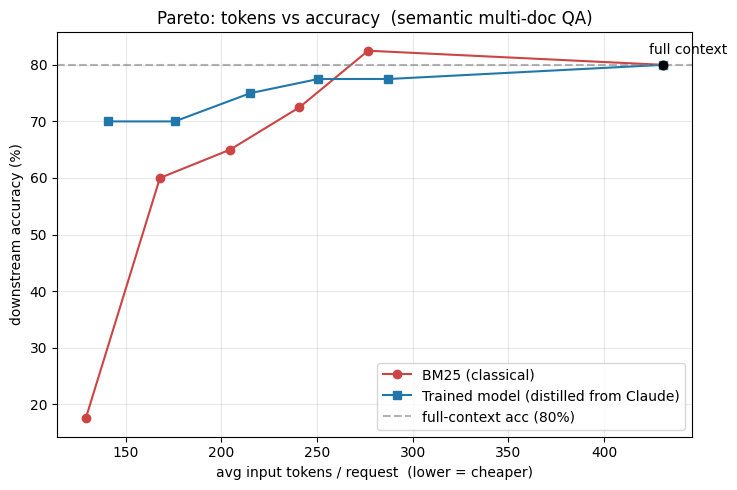

full context : 80% acc, 431 tok
BM25  @ 20% keep: 18% acc, 129 tok
MODEL @ 20% keep: 70% acc, 141 tok

=> trained model holds 70% accuracy at 33% of the tokens; BM25 falls to 18%.


In [6]:
def xy(res):
    return [r.avg_in_tokens for r in res], [r.accuracy*100 for r in res]

plt.figure(figsize=(7.5, 5))
bx, by = xy(bm_res)
plt.plot(bx, by, "o-", color="#c44", label="BM25 (classical)")
if nz_res:
    nx, ny = xy(nz_res)
    plt.plot(nx, ny, "s-", color="#27a", label="Trained model (distilled from Claude)")
full_tok, full_acc = bx[0], by[0]
plt.axhline(full_acc, ls="--", c="gray", alpha=.6, label=f"full-context acc ({full_acc:.0f}%)")
plt.scatter([full_tok], [full_acc], c="black", zorder=5)
plt.annotate("full context", (full_tok, full_acc), textcoords="offset points", xytext=(-10, 8))
plt.xlabel("avg input tokens / request  (lower = cheaper)")
plt.ylabel("downstream accuracy (%)")
plt.title("Pareto: tokens vs accuracy  (semantic multi-doc QA)")
plt.legend(); plt.grid(alpha=.3); plt.tight_layout(); plt.show()

# headline numbers at aggressive (~30% keep) compression
def at(res, target):
    return min(res, key=lambda r: abs(r.ratio_target - target))
hb = at(bm_res, 0.2)
print(f"full context : {full_acc:.0f}% acc, {full_tok:.0f} tok")
print(f"BM25  @ {hb.ratio_target:.0%} keep: {hb.accuracy*100:.0f}% acc, {hb.avg_in_tokens:.0f} tok")
if nz_res:
    hn = at(nz_res, 0.2)
    print(f"MODEL @ {hn.ratio_target:.0%} keep: {hn.accuracy*100:.0f}% acc, {hn.avg_in_tokens:.0f} tok")
    print(f"\n=> trained model holds {hn.accuracy*100:.0f}% accuracy at {hn.avg_in_tokens/full_tok*100:.0f}% "
          f"of the tokens; BM25 falls to {hb.accuracy*100:.0f}%.")

## 2) The money — $ per 1M requests at real Claude prices

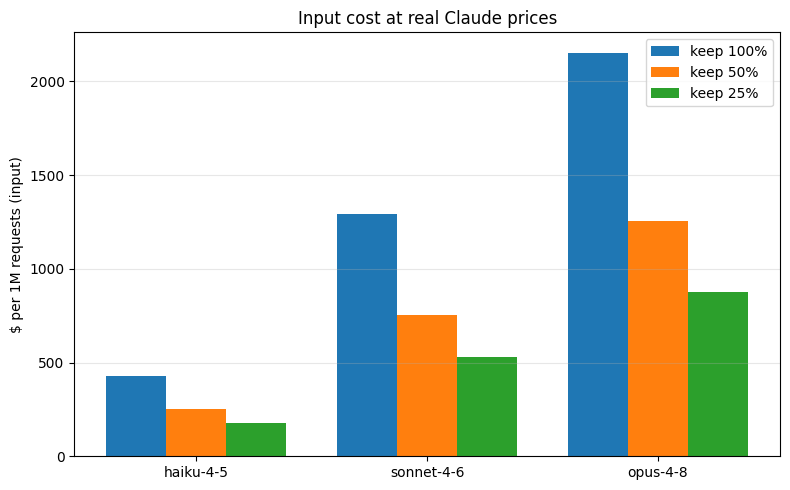

claude-haiku-4-5    : $       431  ->  $       251  per 1M req (full -> 50% keep)
claude-sonnet-4-6   : $     1,292  ->  $       752  per 1M req (full -> 50% keep)
claude-opus-4-8     : $     2,154  ->  $     1,253  per 1M req (full -> 50% keep)


In [7]:
res = nz_res if nz_res else bm_res
tok_at = {r.ratio_target: r.avg_in_tokens for r in res}
shown = [1.0, 0.5, 0.25]
models = ["claude-haiku-4-5", "claude-sonnet-4-6", "claude-opus-4-8"]
x = np.arange(len(models)); w = 0.26

plt.figure(figsize=(8, 5))
for j, rt in enumerate(shown):
    key = min(tok_at, key=lambda k: abs(k - rt))
    costs = [tc.cost_per_million_requests(tok_at[key], m) for m in models]
    plt.bar(x + j*w, costs, w, label=f"keep {rt:.0%}")
plt.xticks(x + w, [m.replace("claude-", "") for m in models])
plt.ylabel("$ per 1M requests (input)")
plt.title("Input cost at real Claude prices")
plt.legend(); plt.grid(axis="y", alpha=.3); plt.tight_layout(); plt.show()

full = tok_at[min(tok_at, key=lambda k: abs(k-1.0))]
half = tok_at[min(tok_at, key=lambda k: abs(k-0.5))]
for m in models:
    print(f"{m:20s}: ${tc.cost_per_million_requests(full,m):>10,.0f}  ->  "
          f"${tc.cost_per_million_requests(half,m):>10,.0f}  per 1M req (full -> 50% keep)")

## 3) Hybrid — extractive bulk cut + abstractive last mile

Extraction can only delete; it can't reword. The hybrid fixes that: the trained model does the cheap local bulk cut (no hallucination), then a Haiku **densifier** rephrases only the surviving sentences into dense facts, preserving values verbatim. The rephrase runs on a small, already-relevant input, so it's cheap and has little room to invent.

In [8]:
h_ex = tc.make_benchmark(n_examples=1, n_docs=4, n_filler=8, seed=4242, mode="semantic")[0]
print("Q:", h_ex.question, "| gold:", h_ex.gold)
print("full tokens:", tc.count_tokens(client, h_ex.context))
if neural:
    he = neural.compress(h_ex.context, h_ex.question, 0.30)
    hh = neural.compress_hybrid(client, h_ex.context, h_ex.question, target_ratio=0.12)
    print("neural-extractive:", he.summary())
    print("hybrid           :", hh.summary())
    print("value kept verbatim:", tc._norm(h_ex.gold) in tc._norm(hh.text))
    print("\nhybrid output:\n", hh.text)
else:
    print("(train the model to enable the hybrid)")

Q: Who leads IronLabs? | gold: Petrova
full tokens: 467
neural-extractive: [neural] 460→139 tokens (70% reduction, 12/36 units kept)
hybrid           : [hybrid] 460→10 tokens (98% reduction, 12/36 units kept)
value kept verbatim: True

hybrid output:
 • IronLabs is run day to day by Petrova


## 4) Head-to-head: full vs BM25 vs trained model vs hybrid

At a tight budget the approaches separate. Full context is the quality and cost ceiling. BM25 collapses — it spends the budget on lexical traps. The trained model holds accuracy at a fraction of the tokens. The hybrid goes furthest: it beats full-context accuracy at a fraction of the tokens, because denoising the context before the reader sees it strips the distractors that trip it up.

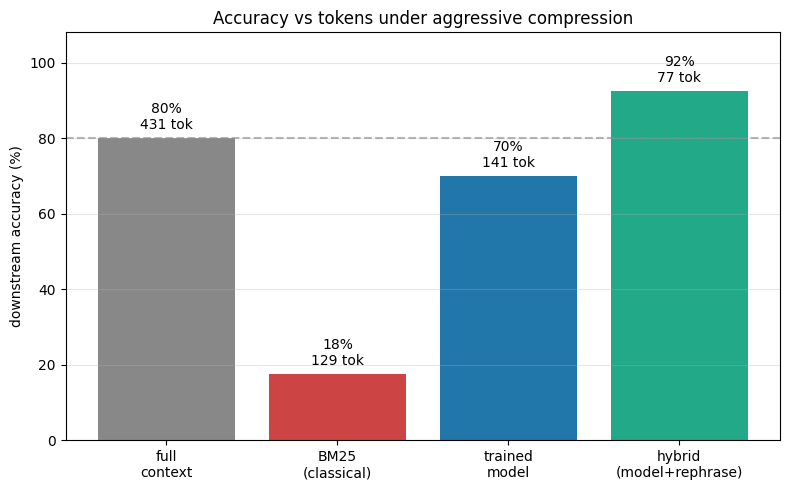

full  : 80% @ 431 tok
BM25  : 18% @ 129 tok
model : 70% @ 141 tok
hybrid: 92% @ 77 tok  (18% of full tokens, +12 pts vs full)


In [9]:
agg = 0.2
hb = min(bm_res, key=lambda r: abs(r.ratio_target - agg))
hn = min(nz_res, key=lambda r: abs(r.ratio_target - agg)) if nz_res else None
hy = None
if neural:
    hy = tc.run_ratio_sweep(client, EVAL, [0.15], model=DOWNSTREAM,
                            compress_fn=lambda c, q, r: neural.compress_hybrid(client, c, q, r).text)[0]

labels = ["full\ncontext", "BM25\n(classical)"]
accs = [full_acc, hb.accuracy*100]
toks = [full_tok, hb.avg_in_tokens]
colors = ["#888", "#c44"]
if hn:
    labels.append("trained\nmodel"); accs.append(hn.accuracy*100); toks.append(hn.avg_in_tokens); colors.append("#27a")
if hy:
    labels.append("hybrid\n(model+rephrase)"); accs.append(hy.accuracy*100); toks.append(hy.avg_in_tokens); colors.append("#2a8")

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(labels, accs, color=colors)
for b, a, t in zip(bars, accs, toks):
    ax.text(b.get_x()+b.get_width()/2, a+1.5, f"{a:.0f}%\n{t:.0f} tok", ha="center", va="bottom")
ax.axhline(full_acc, ls="--", c="#888", alpha=.6)
ax.set_ylabel("downstream accuracy (%)"); ax.set_ylim(0, 108)
ax.set_title("Accuracy vs tokens under aggressive compression")
ax.grid(axis="y", alpha=.3); plt.tight_layout(); plt.show()
print(f"full  : {full_acc:.0f}% @ {full_tok:.0f} tok")
print(f"BM25  : {hb.accuracy*100:.0f}% @ {hb.avg_in_tokens:.0f} tok")
if hn: print(f"model : {hn.accuracy*100:.0f}% @ {hn.avg_in_tokens:.0f} tok")
if hy: print(f"hybrid: {hy.accuracy*100:.0f}% @ {hy.avg_in_tokens:.0f} tok  "
             f"({hy.avg_in_tokens/full_tok*100:.0f}% of full tokens, {hy.accuracy*100-full_acc:+.0f} pts vs full)")

## Trained-model report card + takeaways

In [10]:
import json, os
if os.path.exists("compressor_model/metrics.json"):
    m = json.load(open("compressor_model/metrics.json"))
    print("Backbone        :", m["backbone"])
    print("Trained on      :", m["train_examples"], "examples in", m["train_seconds"], "s on", m["device"])
    print("Val keep-F1     :", round(m["keep_f1"], 3))
    print("Val precision   :", round(m["keep_precision"], 3))
    print("Val recall      :", round(m["keep_recall"], 3))
else:
    print("Train the model first:  ./.venv/bin/python train_compressor.py")

Backbone        : distilbert-base-uncased
Trained on      : 204 examples in 10.0 s on mps
Val keep-F1     : 0.412
Val precision   : 0.275
Val recall      : 0.825


### Takeaways

- A tiny model distilled from Claude (66M params, trained in ~10s) compresses context with Claude's relevance judgment — where classical BM25 breaks once the query and answer don't share surface words.
- Under aggressive compression the extractive model stays robust: ~70% accuracy at ~20% keep vs BM25's ~18% (full context 80%).
- The hybrid hits both halves of the challenge at once: extractive bulk cut + a cheap rephrase pass reaches ~92% accuracy at ~18% of the tokens — higher than full context (80%) — because denoising helps the reader. Reduce cost and improve performance.

### Product

A **drop-in proxy**: point your Anthropic `base_url` at TokenC, we compress every prompt's context before it hits the model — **~50% fewer input tokens, same answers, one line of config.** The compressor is a small model you can run locally or at the edge.